In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
import shap
from shap.plots import waterfall
import lime

from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils.helpers import Helpers

In [2]:
helper = Helpers()
properties = helper.load_properties()

try:
    RANDOM_STATE = properties['models']['random_state']
except KeyError as ke:
    raise KeyError(f"Missing key in properties file: {str(ke)}") from ke

In [3]:
# Apply global settings
helper.set_global_settings()

In [4]:
target_variable = 'loan_status'
parent_data_dir = helper.root_dir / "datasets"

train_df = pd.read_csv(parent_data_dir / "sampled_train_data.csv")
test_df = pd.read_csv(parent_data_dir / "test_set.csv")

X_train = train_df.drop(columns=[target_variable])
y_train = train_df[target_variable]

X_test = test_df.drop(columns=[target_variable])
y_test = test_df[target_variable]

In [5]:
parent_model_dir = helper.root_dir / "models"

with open(parent_model_dir / "best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(parent_model_dir / "power_transformer.pkl", "rb") as f:
    transformer = pickle.load(f)

 99%|===================| 4191/4254 [01:14<00:01]        

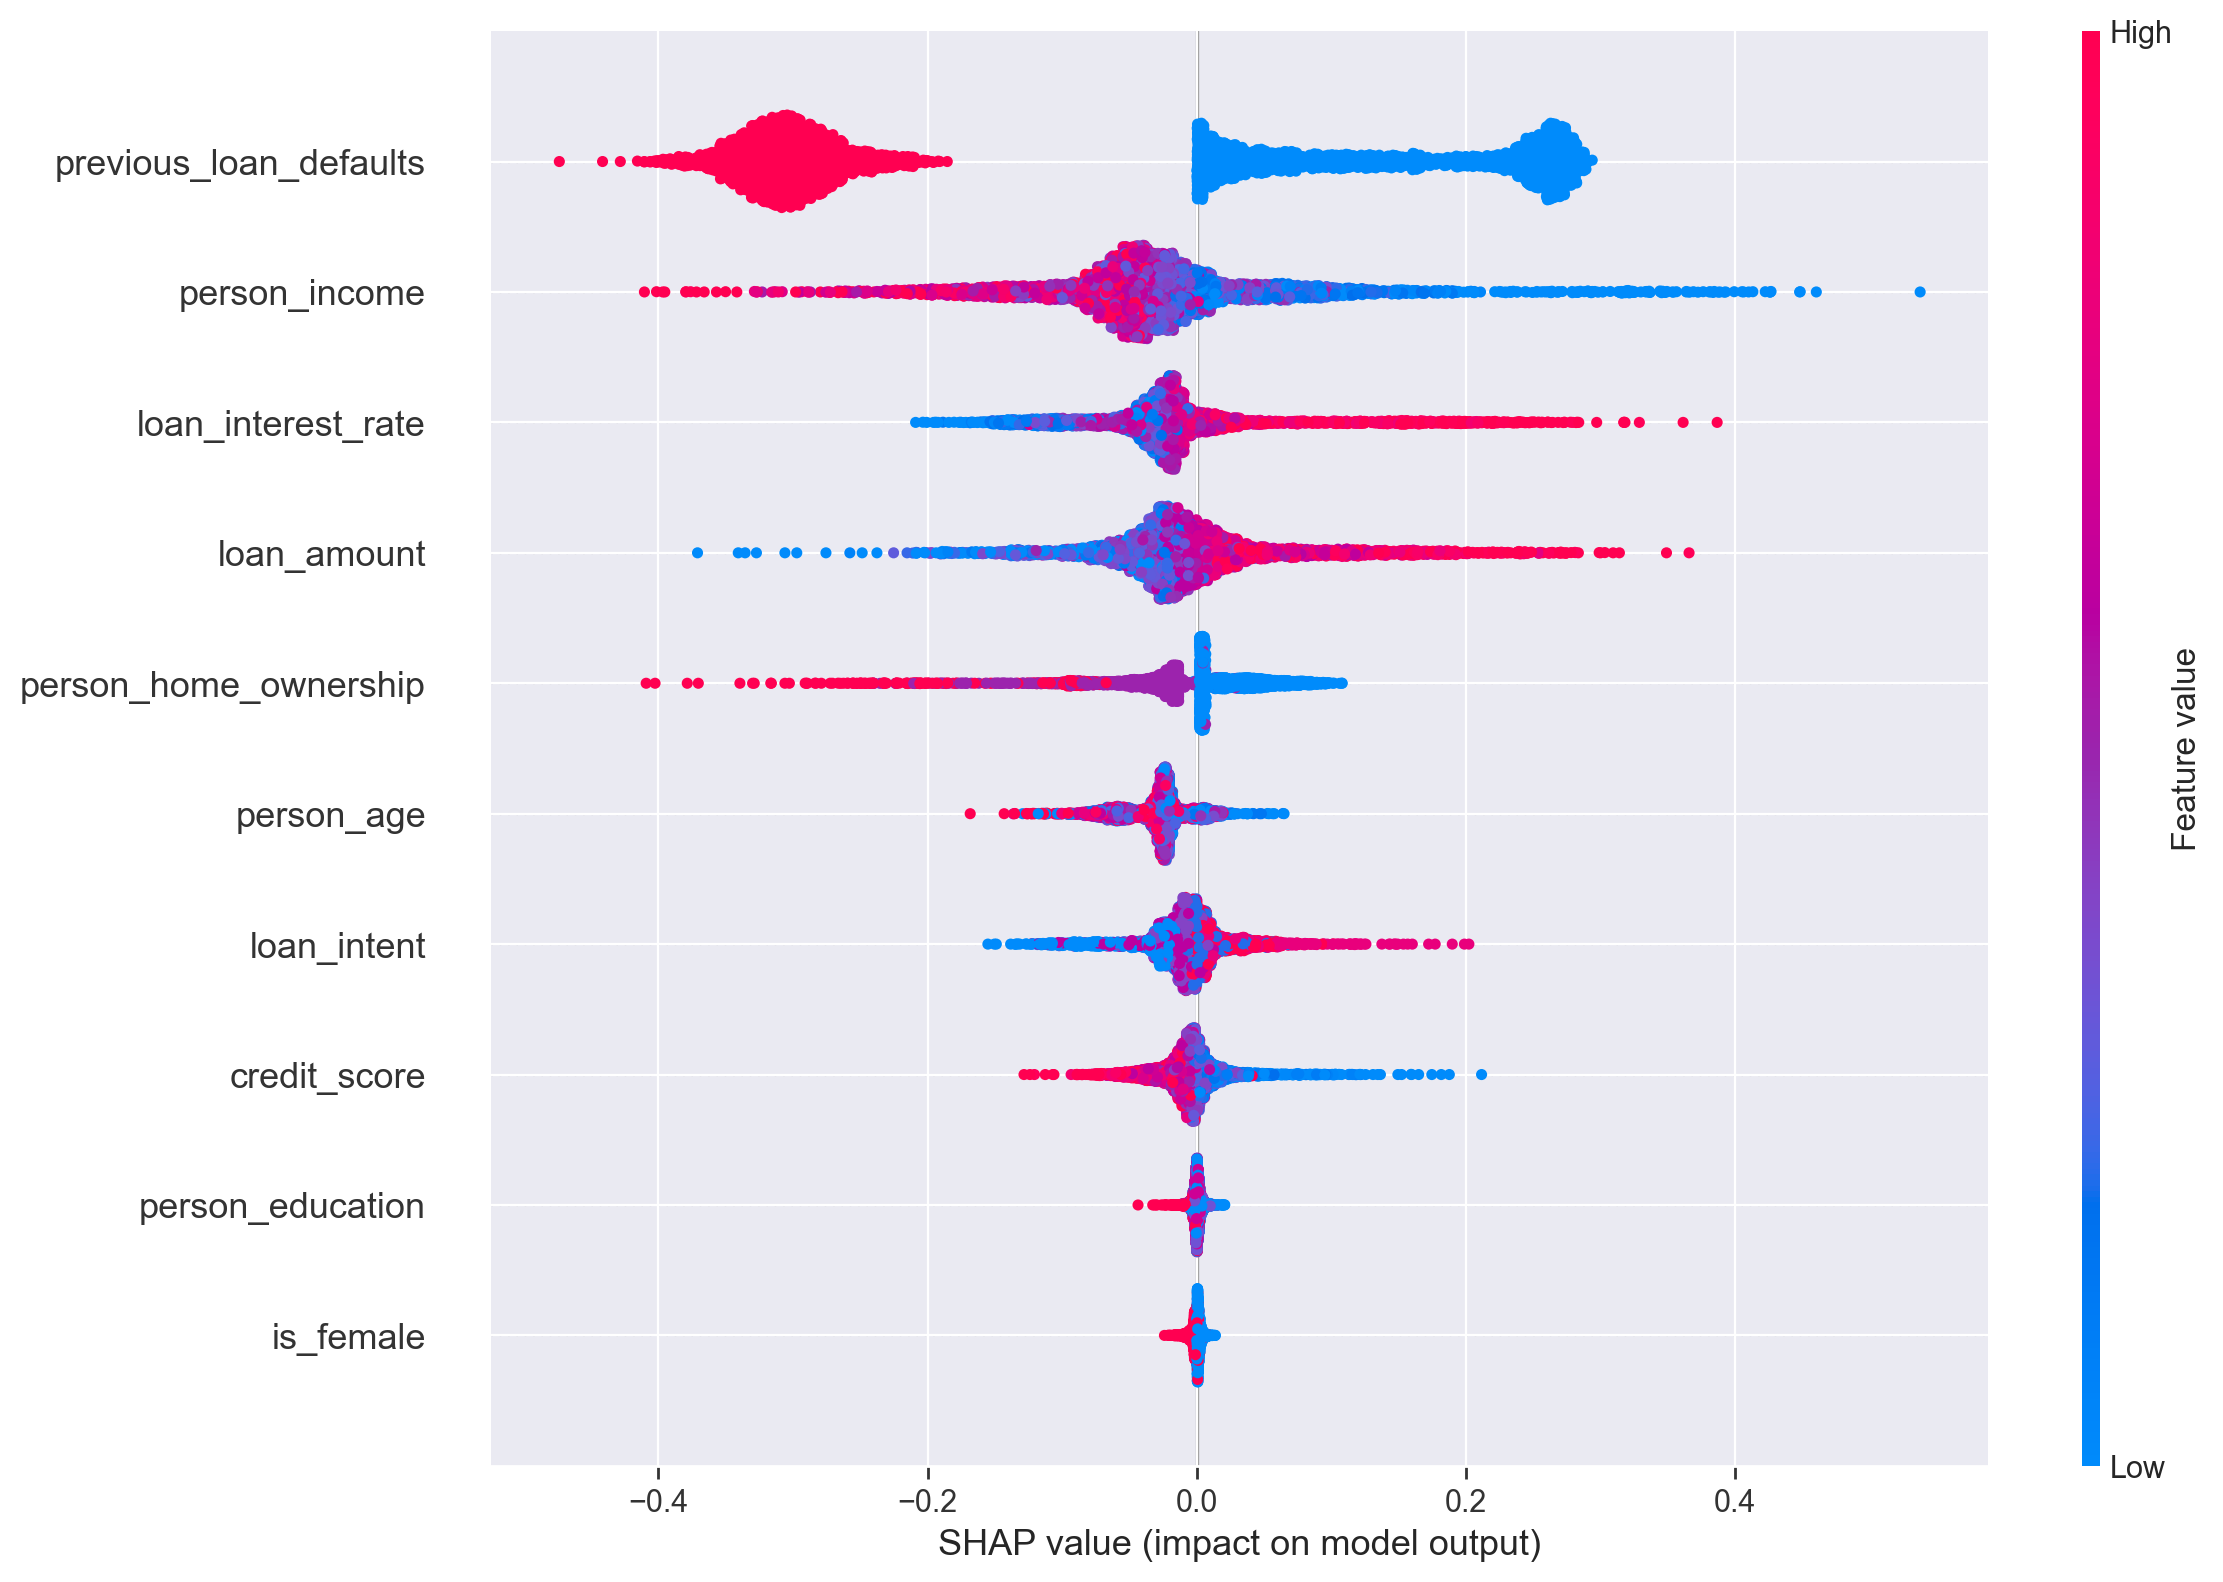

<Figure size 1280x960 with 0 Axes>

In [6]:
explainer = shap.TreeExplainer(
    model, 
    X_train, 
    model_output='probability', 
    feature_perturbation="interventional", 
    feature_names=X_train.columns
    )
shap_values = explainer.shap_values(X_test, y_test)

shap.summary_plot(shap_values, X_test, plot_size=(12,8))
plt.tight_layout()

In [7]:
num_variables = ['person_age', 'person_income', 'loan_amount', 'loan_interest_rate', 'credit_score']

X_test_inv = helper.reverse_power_transform(X_test, num_variables, transformer)

X_test_inv.head()

,person_age,is_female,person_education,person_income,person_home_ownership,loan_amount,loan_intent,loan_interest_rate,credit_score,previous_loan_defaults
0,22.00,0,1,89882.00,2,9000.00,3,11.01,634.00,1
1,26.00,0,2,140836.00,1,7500.00,4,11.59,651.00,1
2,25.00,0,1,132975.00,2,7000.00,0,10.06,658.00,0
3,26.00,1,1,84906.00,2,5000.00,3,9.88,703.00,1
4,21.00,0,2,126342.00,2,19200.00,1,11.99,502.00,1


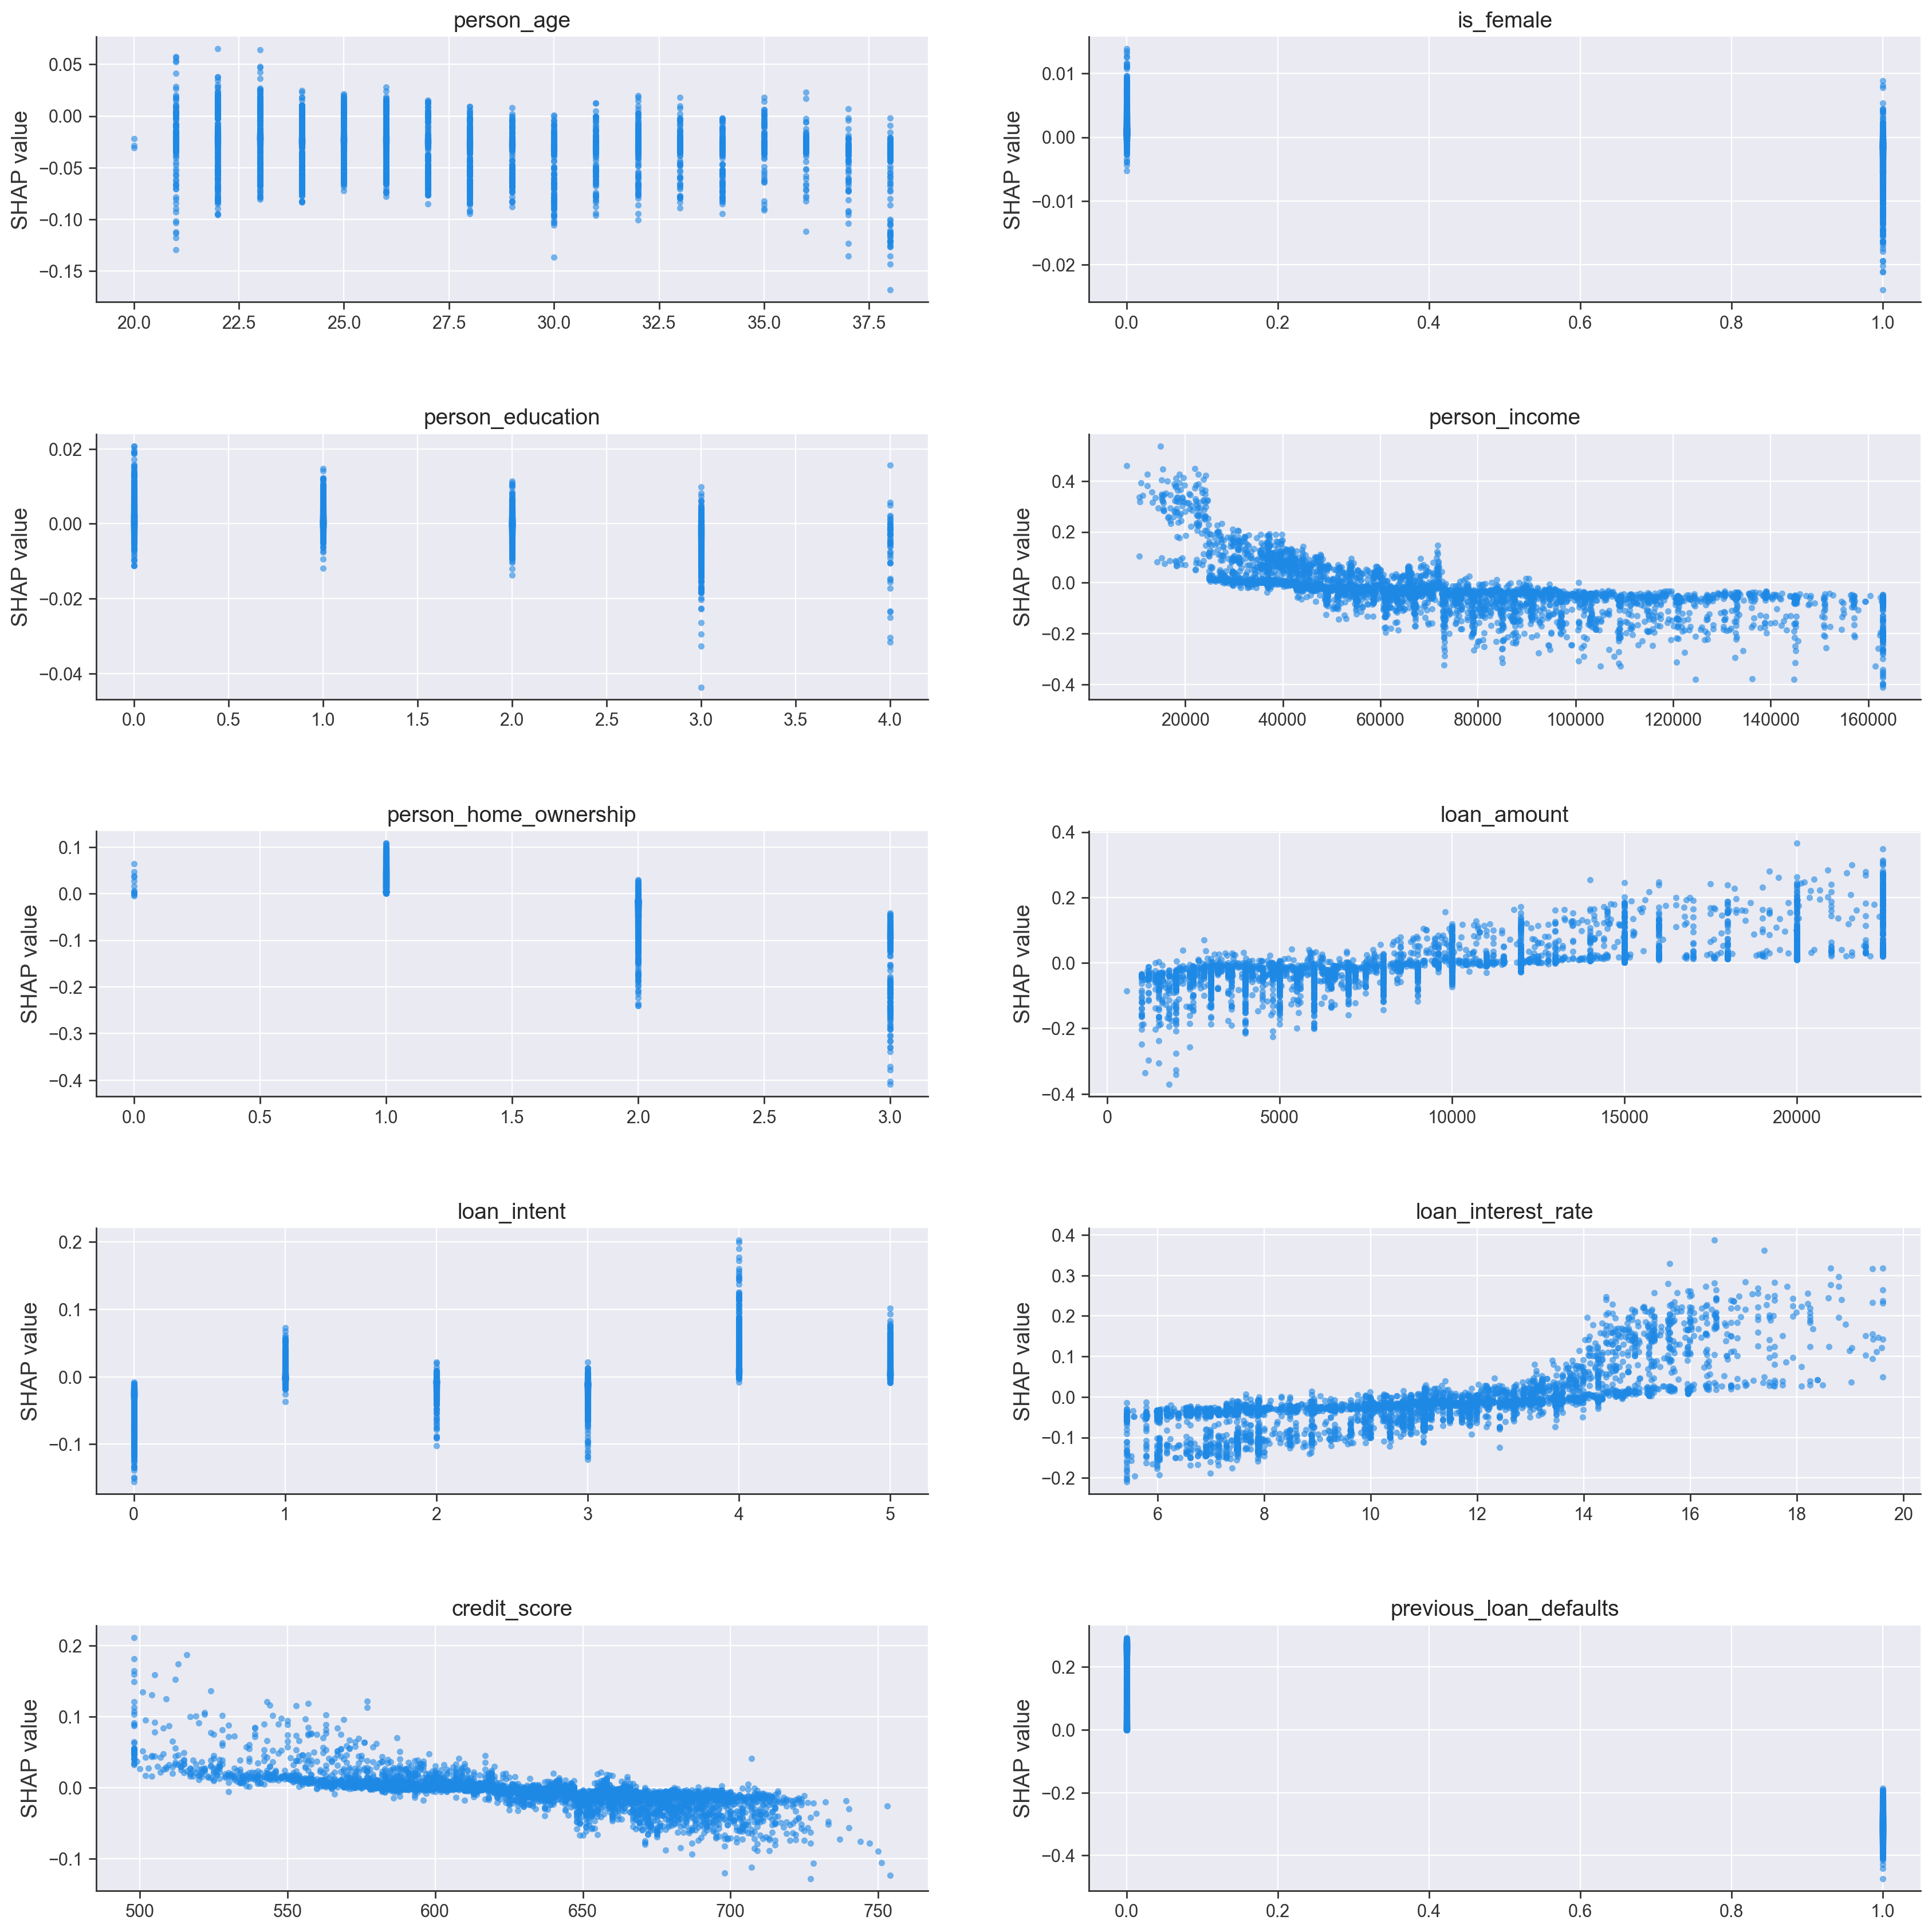

In [ ]:
features = X_train.columns.to_list()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18,18))
axes = axes.flatten()

for ax, f in zip(axes, features):
    plt.sca(ax)
    shap.dependence_plot(
        f,
        shap_values,
        X_test,
        interaction_index=None,
        alpha=0.6,
        ax=ax,
        show=False
    )
    ax.set_title(f, fontsize=14)
    ax.set_ylabel("SHAP value", fontsize=14)
    ax.set_xlabel("")

plt.tight_layout(pad=5)
plt.show()

In [9]:
import numpy as np

shap_explanation_object = explainer(X_test)

# predicted probabilities for positive class
y_proba = model.predict_proba(X_test)[:, 1]

# most positive prediction
pos_idx = np.argmax(y_proba)

# most negative prediction
neg_idx = np.argmin(y_proba)

print("Positive index:", pos_idx, "prob:", y_proba[pos_idx])
print("Negative index:", neg_idx, "prob:", y_proba[neg_idx])

 99%|===================| 4191/4254 [01:11<00:01]        

Positive index: 3549 prob: 0.9999272125922039
Negative index: 2301 prob: 3.4087577812908698e-06


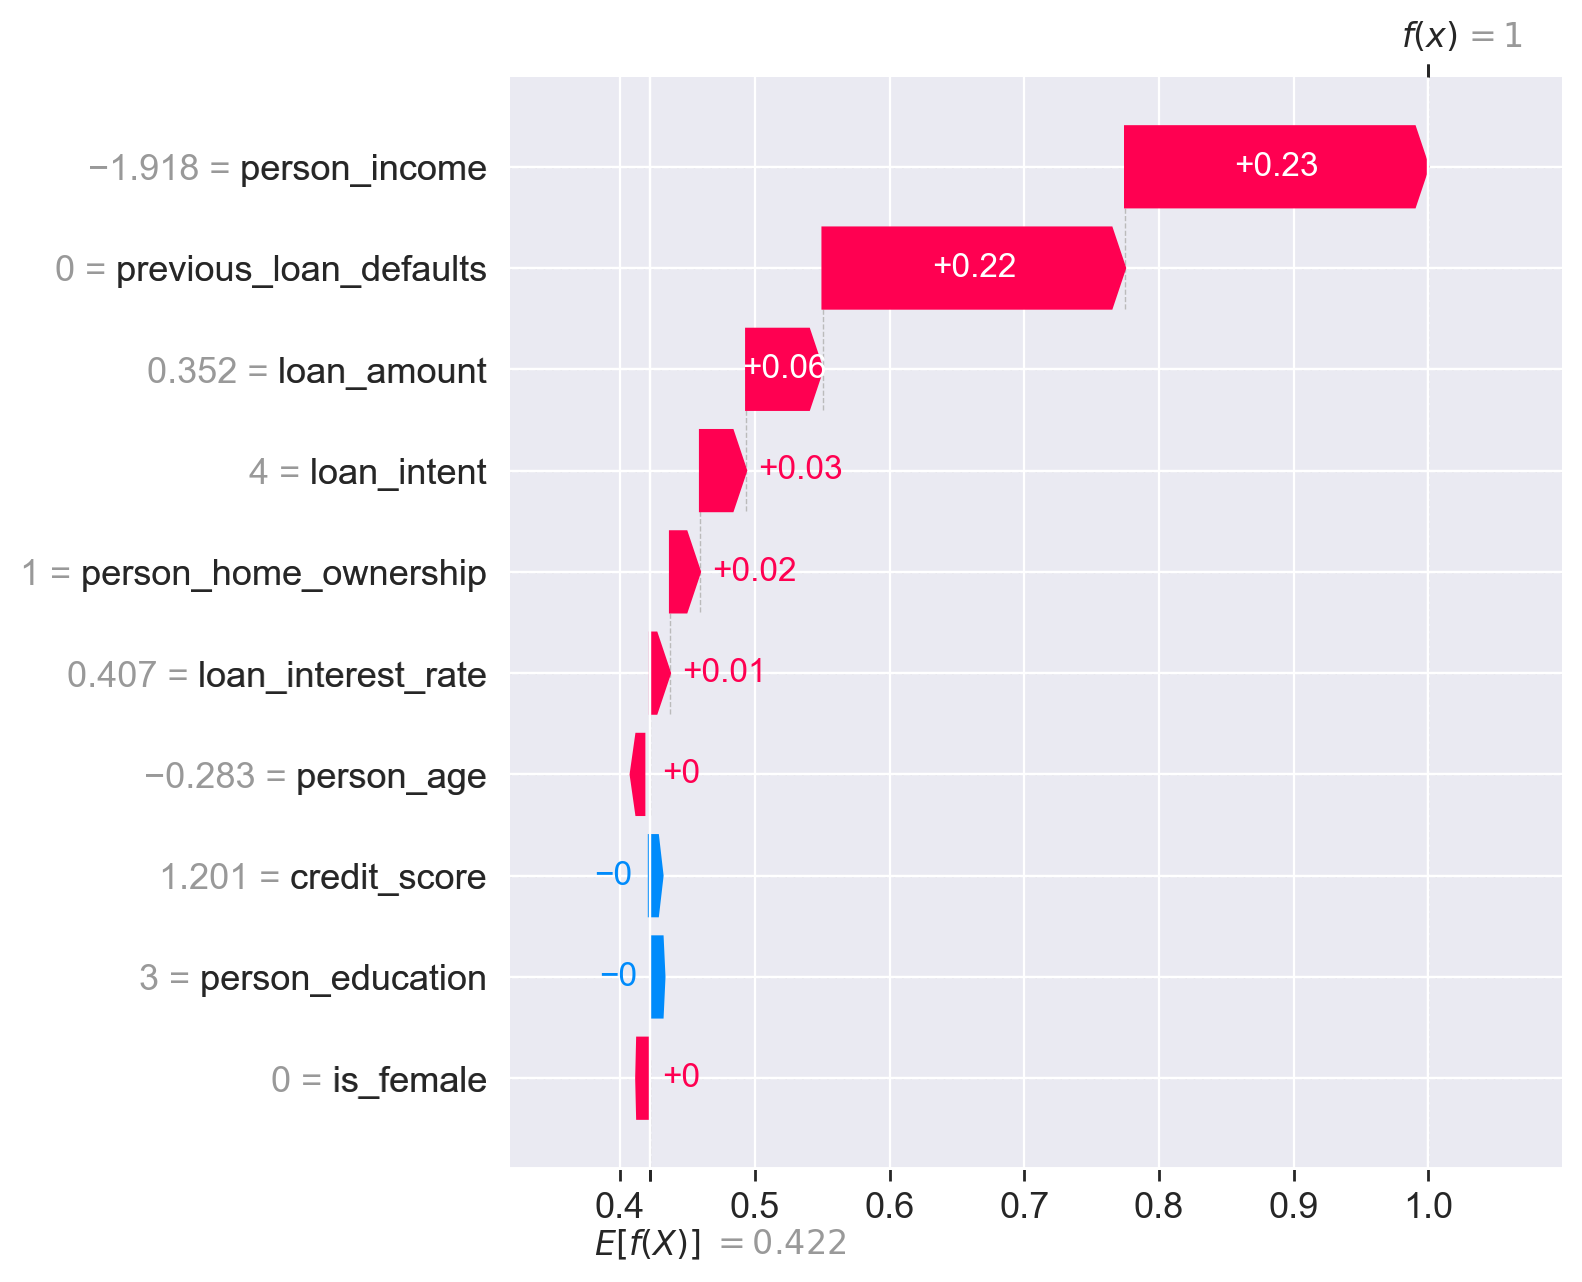

In [10]:
plt.figure(figsize=(20,12))
waterfall(shap_explanation_object[pos_idx], show=False)
plt.tight_layout()
plt.show()

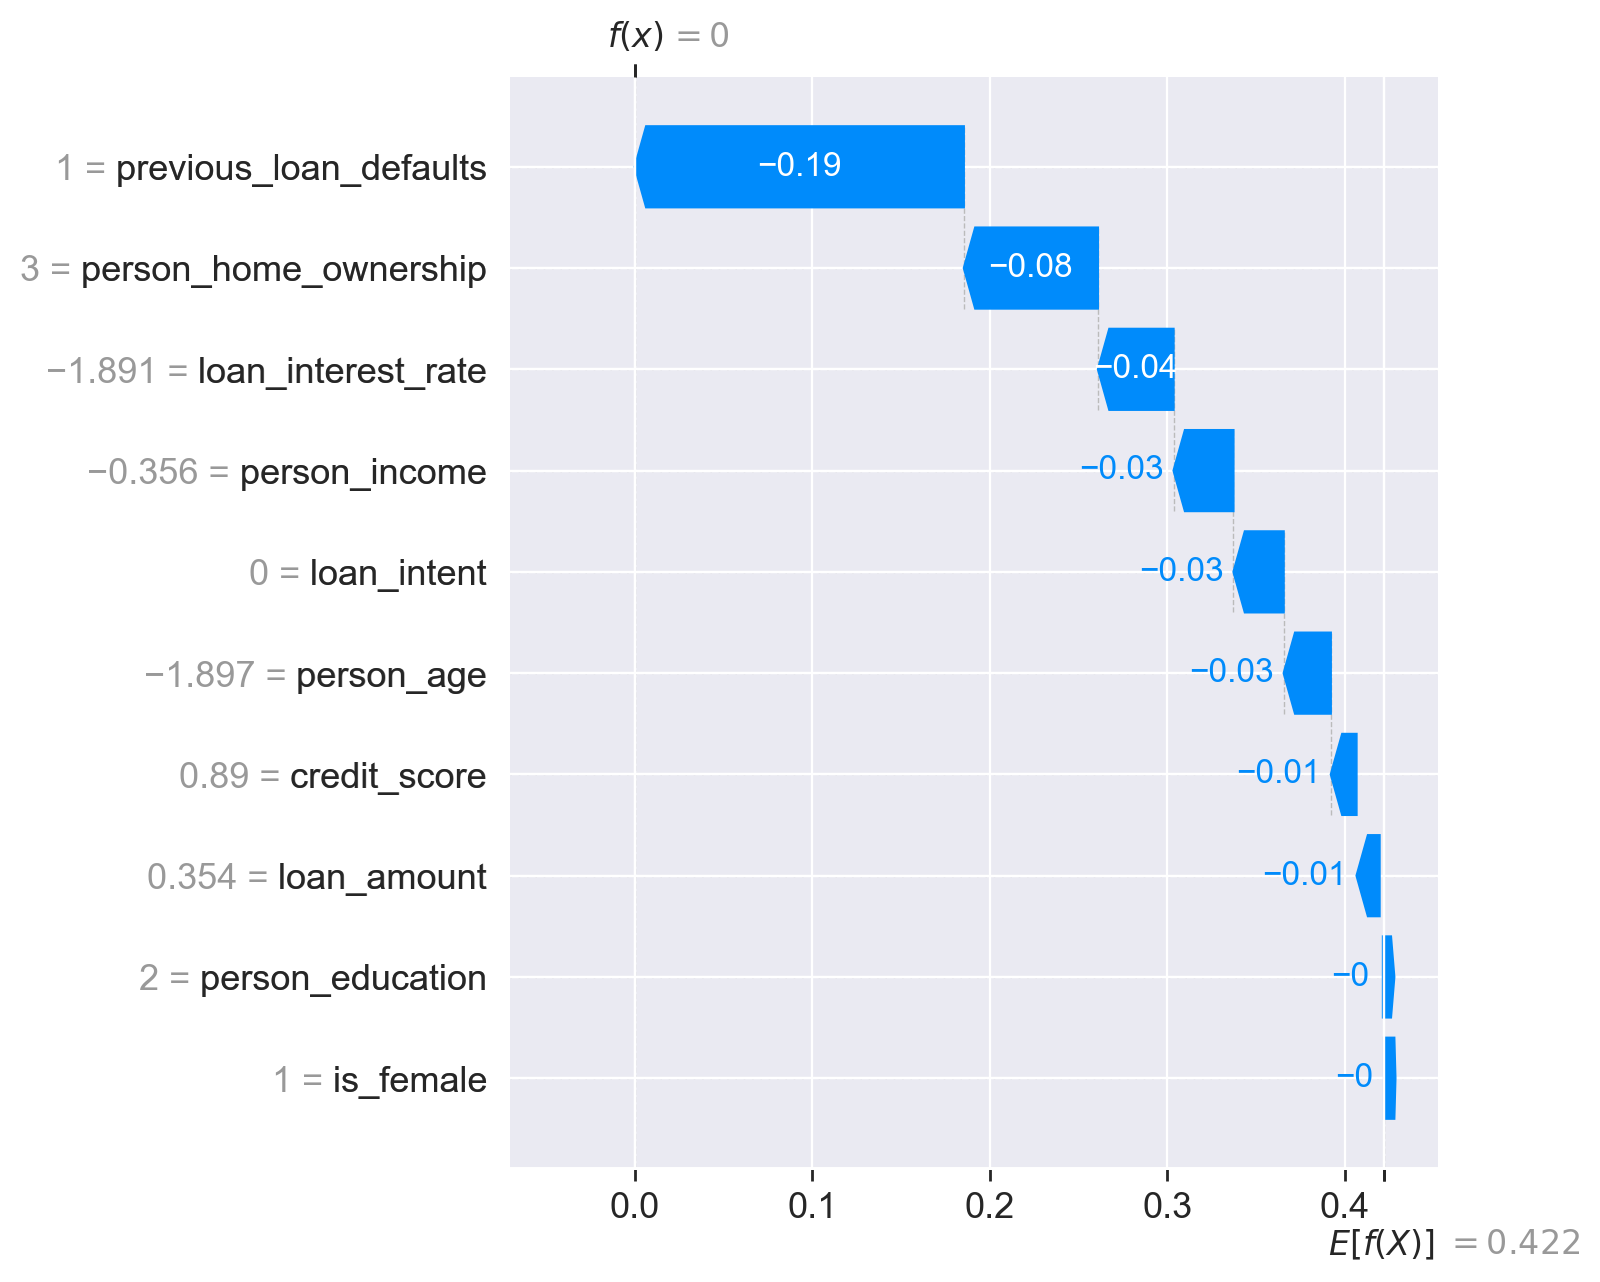

In [11]:
plt.figure(figsize=(10,6))
waterfall(shap_explanation_object[neg_idx], show=False)
plt.tight_layout()
plt.show()

In [15]:
X_test_inv.loc[pos_idx,:]

person_age                  25.00
is_female                    0.00
person_education             3.00
person_income            22735.00
person_home_ownership        1.00
loan_amount               9988.00
loan_intent                  4.00
loan_interest_rate          12.07
credit_score               687.00
previous_loan_defaults       0.00
Name: 3549, dtype: float64

In [16]:
X_test_inv.loc[neg_idx,:]

person_age                  21.00
is_female                    1.00
person_education             2.00
person_income            56241.00
person_home_ownership        3.00
loan_amount              10000.00
loan_intent                  0.00
loan_interest_rate           5.79
credit_score               675.00
previous_loan_defaults       1.00
Name: 2301, dtype: float64

In [31]:
shap_explanation_object[neg_idx].feature_names

['person_age',
 'is_female',
 'person_education',
 'person_income',
 'person_home_ownership',
 'loan_amount',
 'loan_intent',
 'loan_interest_rate',
 'credit_score',
 'previous_loan_defaults']

In [47]:
shap_explanation_object.base_values[0]

np.float64(0.4221268459190929)

In [33]:
shap_explanation_object[neg_idx].values

array([-0.02655308, -0.00062808, -0.00187623, -0.03375162, -0.07554973,
       -0.01299369, -0.02829229, -0.04259569, -0.01449375, -0.18538929])

In [42]:
shifted_shap = shap_explanation_object[neg_idx].values + shap_explanation_object[neg_idx].base_values/len(features)
sum(shifted_shap)

np.float64(3.406783408765879e-06)

In [43]:
dict(zip(shap_explanation_object[pos_idx].feature_names, shifted_shap))

{'person_age': np.float64(0.015659605968916124),
 'is_female': np.float64(0.041584605374888006),
 'person_education': np.float64(0.040336451904229215),
 'person_income': np.float64(0.008461069319607384),
 'person_home_ownership': np.float64(-0.03333704748852266),
 'loan_amount': np.float64(0.02921899135770322),
 'loan_intent': np.float64(0.013920399104125885),
 'loan_interest_rate': np.float64(-0.0003830035331333151),
 'credit_score': np.float64(0.02771893796867587),
 'previous_loan_defaults': np.float64(-0.14317660319308095)}